## Reinforcement Learning Trading Bot - EUR/USD Forex
### Train a DQN Agent on real EUR/USD data from yfinance

## Install Dependencies

In [2]:
!pip install numpy pandas matplotlib yfinance stable-baselines3 gymnasium scikit-learn torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 7.0 MB/s eta 0:00:00


## Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('✅ All imports successful')

✅ All imports successful


## Config

In [5]:
# ── Data ─────────────────────────────────────────────────────────────
TICKER        = 'EURUSD=X'
START_DATE    = '2021-01-01'
END_DATE      = '2024-12-31'
TRAIN_SPLIT   = 0.80          # fraction used for training

# ── Environment ───────────────────────────────────────────────────────
WINDOW_SIZE       = 20          # lookback steps in observation
INITIAL_BALANCE   = 10_000.0
TRADE_SIZE        = 0.01        # lot size
SPREAD_PIPS       = 0.0002      # 2-pip spread (realistic for EUR/USD)
RUIN_THRESHOLD    = 0.50        # terminate if balance falls below 50% of initial

# ── DQN Hyperparameters ───────────────────────────────────────────────
LEARNING_RATE          = 1e-4
BUFFER_SIZE            = 50_000
LEARNING_STARTS        = 500
BATCH_SIZE             = 64
TAU                    = 0.005   # soft target update (was 1.0 — hard update)
GAMMA                  = 0.99
TRAIN_FREQ             = 4
TARGET_UPDATE_INTERVAL = 1       # soft updates work best with update_interval=1
EXPLORATION_FRACTION   = 0.30
EXPLORATION_INITIAL    = 1.0
EXPLORATION_FINAL      = 0.05
NET_ARCH               = [256, 256, 128]
TOTAL_TIMESTEPS        = 100_000  # doubled for better convergence
SEED                   = 42

print('✅ Config loaded')

✅ Config loaded


## Download EUR/USD Data from yfinance

In [6]:
print('Downloading EUR/USD data from yfinance...')

df = yf.download(TICKER, start=START_DATE, end=END_DATE,
                 interval='1d', auto_adjust=True, progress=False)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
df.index = pd.to_datetime(df.index)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'✅ Downloaded {len(df)} rows')
print(f'   Date range : {df.index[0].date()} to {df.index[-1].date()}')
print(f'   Columns    : {list(df.columns)}')
df.tail()

✅ Downloaded 1042 rows
   Date range : 2021-01-01 to 2024-12-30
   Columns    : ['Open', 'High', 'Low', 'Close', 'Volume']


Price,Open,High,Low,Close,Volume
Date,,,,,
2024-12-24,1.040583,1.041124,1.038745,1.040583,0
2024-12-25,1.040258,1.043297,1.040150,1.040258,0
2024-12-26,1.039955,1.042535,1.039145,1.039955,0
2024-12-27,1.042318,1.044495,1.040669,1.042318,0
2024-12-30,1.042938,1.045850,1.037420,1.042938,0


## Feature Engineering

In [7]:
def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Add technical indicators as RL state features."""
    df = df.copy()

    # Returns and price features
    df['Returns']     = df['Close'].pct_change()
    df['HL_Ratio']    = (df['High'] - df['Low']) / df['Close']
    df['OC_Ratio']    = (df['Close'] - df['Open']) / df['Open']

    # Moving Averages
    df['SMA_5']       = df['Close'].rolling(5).mean()
    df['SMA_20']      = df['Close'].rolling(20).mean()
    df['SMA_50']      = df['Close'].rolling(50).mean()
    df['EMA_12']      = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26']      = df['Close'].ewm(span=26, adjust=False).mean()

    # MACD
    df['MACD']        = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

    # RSI (14)
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-10)
    df['RSI']         = 100 - (100 / (1 + rs))

    # Bollinger Bands
    bb_mid            = df['Close'].rolling(20).mean()
    bb_std            = df['Close'].rolling(20).std()
    df['BB_Upper']    = bb_mid + 2 * bb_std
    df['BB_Lower']    = bb_mid - 2 * bb_std
    df['BB_Width']    = (df['BB_Upper'] - df['BB_Lower']) / (bb_mid + 1e-10)
    df['BB_Pos']      = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'] + 1e-10)

    # ATR (14)
    prev_close        = df['Close'].shift(1)
    tr                = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - prev_close).abs(),
        (df['Low']  - prev_close).abs()
    ], axis=1).max(axis=1)
    df['ATR']         = tr.rolling(14).mean()

    # Price distance from MAs (normalised)
    df['Dist_SMA5']   = (df['Close'] - df['SMA_5'])  / (df['Close'] + 1e-10)
    df['Dist_SMA20']  = (df['Close'] - df['SMA_20']) / (df['Close'] + 1e-10)
    df['Dist_SMA50']  = (df['Close'] - df['SMA_50']) / (df['Close'] + 1e-10)

    return df.dropna()


df_feat = add_technical_indicators(df)

FEATURE_COLS = [
    'Returns', 'HL_Ratio', 'OC_Ratio',
    'MACD', 'MACD_Signal', 'MACD_Hist',
    'RSI', 'BB_Width', 'BB_Pos',
    'ATR', 'Dist_SMA5', 'Dist_SMA20', 'Dist_SMA50'
]

print(f'✅ Features created: {len(FEATURE_COLS)} indicators')
print(f'   Rows after dropna: {len(df_feat)}')
df_feat[FEATURE_COLS].describe()

✅ Features created: 13 indicators
   Rows after dropna: 993


Price,Returns,HL_Ratio,OC_Ratio,MACD,MACD_Signal,MACD_Hist,RSI,BB_Width,BB_Pos,ATR,Dist_SMA5,Dist_SMA20,Dist_SMA50
count,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,-0.000122,0.006252,0.000008,-0.001099,-0.001086,-0.000014,47.665429,0.030568,0.464422,0.008445,-0.000288,-0.001450,-0.003665
std,0.004676,0.003172,0.000078,0.005383,0.005072,0.001593,16.486412,0.013913,0.328994,0.002427,0.005034,0.010954,0.017840
min,-0.018418,0.001214,-0.000391,-0.014496,-0.011850,-0.004719,0.351352,0.009201,-0.291185,0.004682,-0.018939,-0.036883,-0.048389
25%,-0.002632,0.003991,0.000000,-0.005104,-0.004992,-0.001176,35.160974,0.020039,0.189124,0.006762,-0.003088,-0.009088,-0.016643
50%,-0.000142,0.005509,0.000000,-0.001872,-0.001854,-0.000006,47.290006,0.027866,0.439983,0.007907,-0.000371,-0.001547,-0.005524
75%,0.002631,0.007596,0.000000,0.002681,0.002401,0.001182,60.030691,0.038643,0.747594,0.009920,0.002539,0.005871,0.007586
max,0.018378,0.024472,0.000442,0.013188,0.012377,0.005200,93.878320,0.088502,1.289505,0.016247,0.019421,0.037244,0.050054


## Train / Test Split  +  Fit Scaler on Train Only

In [9]:
split_idx = int(len(df_feat) * TRAIN_SPLIT)

df_train  = df_feat.iloc[:split_idx].reset_index(drop=True)
df_test   = df_feat.iloc[split_idx:].reset_index(drop=True)

# ── Fit scaler ONLY on training data, then reuse for test ─────────────
train_scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaler.fit(df_train[FEATURE_COLS].values)

print(f'Train rows : {len(df_train):,}  ({df_feat.index[0].date()} to {df_feat.index[split_idx-1].date()})')
print(f'Test  rows : {len(df_test):,}  ({df_feat.index[split_idx].date()} to {df_feat.index[-1].date()})')
print(f'✅ Scaler fit on training data only')

Train rows : 794  (2021-03-11 to 2024-03-26)
Test  rows : 199  (2024-03-27 to 2024-12-30)
✅ Scaler fit on training data only


## Visualise Price Data & Indicators

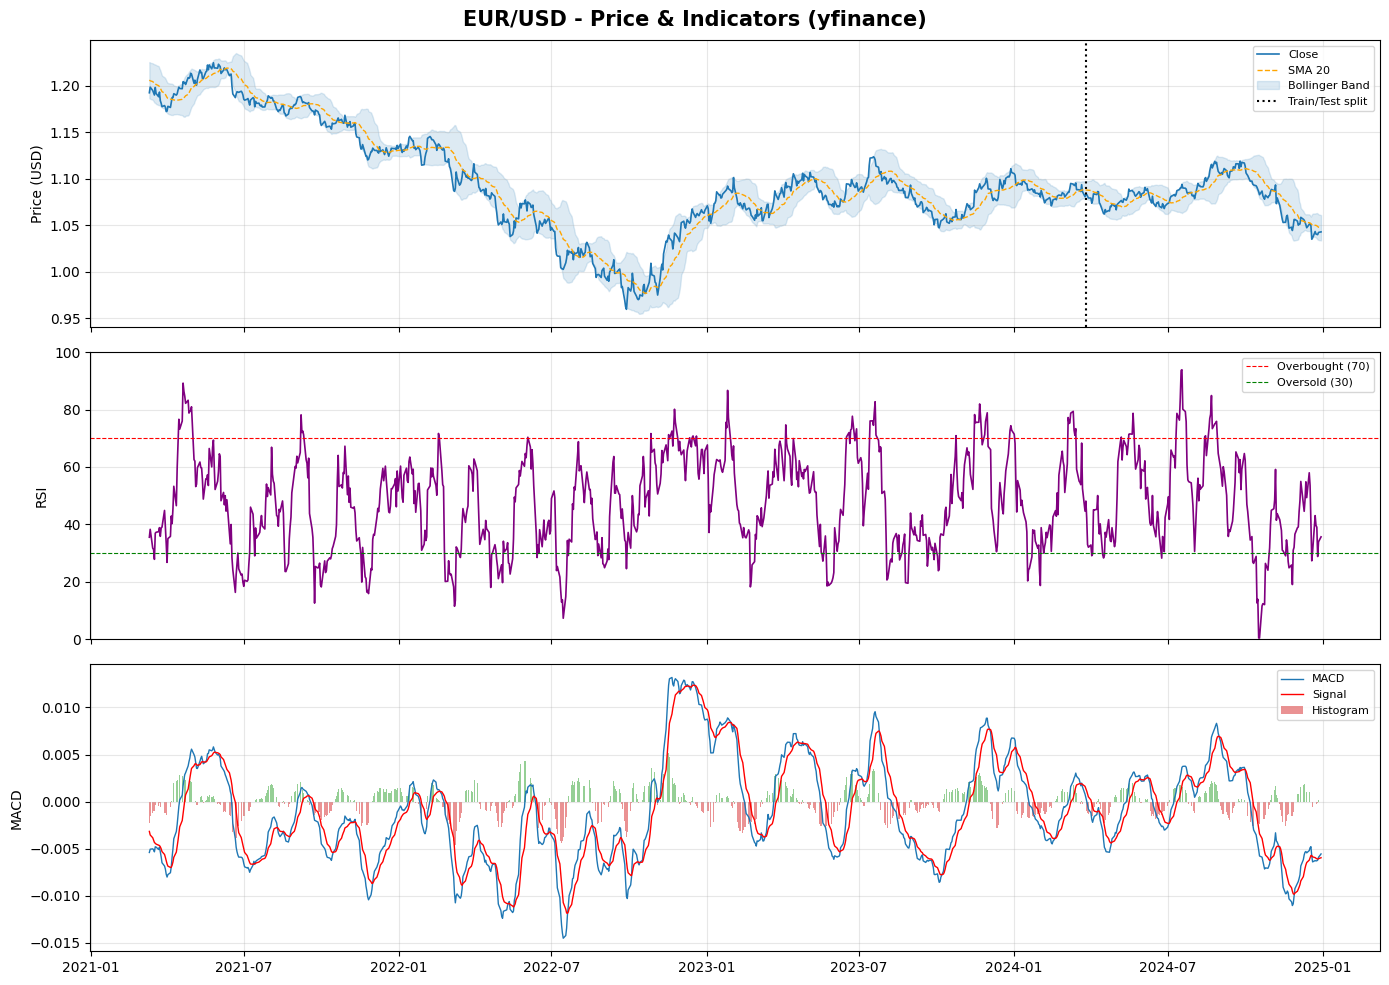

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('EUR/USD - Price & Indicators (yfinance)', fontsize=15, fontweight='bold')

ax = axes[0]
ax.plot(df_feat.index, df_feat['Close'],    color='#1f77b4', lw=1.2, label='Close')
ax.plot(df_feat.index, df_feat['SMA_20'],   color='orange',  lw=1,   linestyle='--', label='SMA 20')
ax.fill_between(df_feat.index, df_feat['BB_Lower'], df_feat['BB_Upper'],
                alpha=0.15, color='#1f77b4', label='Bollinger Band')
ax.axvline(df_feat.index[split_idx - 1], color='black', linestyle=':', lw=1.5, label='Train/Test split')
ax.set_ylabel('Price (USD)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_feat.index, df_feat['RSI'], color='purple', lw=1.2)
ax.axhline(70, color='red',   linestyle='--', lw=0.8, label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', lw=0.8, label='Oversold (30)')
ax.set_ylabel('RSI', fontsize=10)
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(df_feat.index, df_feat['MACD'],        color='#1f77b4', lw=1,   label='MACD')
ax.plot(df_feat.index, df_feat['MACD_Signal'], color='red',     lw=1,   label='Signal')
ax.bar(df_feat.index,  df_feat['MACD_Hist'],
       color=np.where(df_feat['MACD_Hist'] >= 0, '#2ca02c', '#d62728'), alpha=0.5, label='Histogram')
ax.set_ylabel('MACD', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

## Custom Gymnasium Trading Environment

In [11]:
class ForexTradingEnv(gym.Env):
    """
    Custom Gymnasium environment for EUR/USD Forex trading.

    Actions:
        0 = Hold
        1 = Buy  (open long / close short)
        2 = Sell (open short / close long)

    Observation:
        Window of `window_size` recent scaled feature vectors +
        current position (normalised) + cumulative PnL (normalised)

    Key improvements over v1:
        - Accepts a pre-fit `scaler` to prevent train/test data leakage
        - Reward shaped with delta-unrealised PnL each step
        - Spread cost expressed as pips (not raw price × cost_rate)
        - Ruin guard: early termination when balance < RUIN_THRESHOLD
    """

    metadata = {'render_modes': ['human']}

    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: list,
        scaler: MinMaxScaler,          # ← pre-fit scaler (no leakage)
        window_size: int   = WINDOW_SIZE,
        initial_balance: float = INITIAL_BALANCE,
        trade_size: float  = TRADE_SIZE,
        spread_pips: float = SPREAD_PIPS,
        ruin_threshold: float = RUIN_THRESHOLD,
    ):
        super().__init__()

        self.df               = df.reset_index(drop=True)
        self.feature_cols     = feature_cols
        self.window_size      = window_size
        self.initial_balance  = initial_balance
        self.trade_size       = trade_size
        self.spread_pips      = spread_pips          # cost per trade open
        self.ruin_floor       = initial_balance * ruin_threshold

        # Apply pre-fit scaler (fixes data leakage)
        self.scaled = scaler.transform(
            df[feature_cols].values
        ).astype(np.float32)

        n_features             = len(feature_cols)
        obs_size               = window_size * n_features + 2
        self.action_space      = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32
        )

        self._reset_state()

    # ── internal helpers ─────────────────────────────────────────────────

    def _reset_state(self):
        self.current_step     = self.window_size
        self.balance          = self.initial_balance
        self.position         = 0
        self.entry_price      = 0.0
        self.total_pnl        = 0.0
        self.prev_unrealised  = 0.0      # for delta reward shaping
        self.trade_history    = []
        self.portfolio_value  = [self.initial_balance]

    def _get_obs(self) -> np.ndarray:
        window   = self.scaled[
            self.current_step - self.window_size : self.current_step
        ].flatten()
        pnl_norm = self.total_pnl / (self.initial_balance + 1e-10)
        return np.append(window, [float(self.position), pnl_norm]).astype(np.float32)

    def _current_price(self) -> float:
        return float(self.df.loc[self.current_step, 'Close'])

    def _trade_cost(self) -> float:
        """Spread cost: spread_pips * lot_value (100,000 units per lot)."""
        return self.spread_pips * self.trade_size * 100_000

    def _unrealised_pnl(self, price: float) -> float:
        if self.position == 1:
            return (price - self.entry_price) * self.trade_size * 100_000
        if self.position == -1:
            return (self.entry_price - price) * self.trade_size * 100_000
        return 0.0

    # ── Gymnasium API ────────────────────────────────────────────────────

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_state()
        return self._get_obs(), {}

    def step(self, action: int):
        price  = self._current_price()
        reward = 0.0
        cost   = self._trade_cost()

        if action == 1:   # BUY
            if self.position == 0:
                self.position    = 1
                self.entry_price = price
                reward          -= cost
            elif self.position == -1:  # close short
                pnl              = (self.entry_price - price) * self.trade_size * 100_000 - cost
                self.balance    += pnl
                self.total_pnl  += pnl
                reward           = pnl
                self.trade_history.append({'step': self.current_step, 'pnl': pnl, 'side': 'short'})
                self.position    = 0
                self.entry_price = 0.0

        elif action == 2:  # SELL
            if self.position == 0:
                self.position    = -1
                self.entry_price = price
                reward          -= cost
            elif self.position == 1:  # close long
                pnl              = (price - self.entry_price) * self.trade_size * 100_000 - cost
                self.balance    += pnl
                self.total_pnl  += pnl
                reward           = pnl
                self.trade_history.append({'step': self.current_step, 'pnl': pnl, 'side': 'long'})
                self.position    = 0
                self.entry_price = 0.0

        # ── Reward shaping: delta unrealised PnL (gradient signal while holding)
        unrealised      = self._unrealised_pnl(price)
        reward         += unrealised - self.prev_unrealised
        self.prev_unrealised = unrealised

        self.portfolio_value.append(self.balance + unrealised)
        self.current_step += 1

        terminated = self.current_step >= len(self.df) - 1
        truncated  = False

        # Ruin guard (replaces the arbitrary -1000 penalty)
        if self.balance <= self.ruin_floor:
            reward    -= 500
            terminated = True

        return self._get_obs(), float(reward), terminated, truncated, {}

    def render(self):
        price   = self._current_price()
        pos_map = {1: 'LONG', -1: 'SHORT', 0: 'FLAT'}
        print(f'Step {self.current_step:4d} | Price: {price:.5f} | '
              f'Position: {pos_map[self.position]:5s} | '
              f'Balance: ${self.balance:,.2f} | PnL: ${self.total_pnl:+,.2f}')


# Sanity check
env_test = ForexTradingEnv(df_train, FEATURE_COLS, scaler=train_scaler)
obs, _   = env_test.reset()
print(f'✅ Environment created')
print(f'   Observation shape : {obs.shape}')
print(f'   Action space      : {env_test.action_space}')
print(f'   Total steps       : {len(df_train) - env_test.window_size}')

✅ Environment created
   Observation shape : (262,)
   Action space      : Discrete(3)
   Total steps       : 774


## Training Logger Callback

In [12]:
class TrainingLogger(BaseCallback):
    """Collect episode rewards during training."""

    def __init__(self, verbose: int = 0):
        super().__init__(verbose)
        self.episode_rewards: list[float] = []
        self._ep_reward: float = 0.0

    def _on_step(self) -> bool:
        self._ep_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self._ep_reward)
            self._ep_reward = 0.0
        return True

logger_cb = TrainingLogger()
print('✅ Callback ready')

✅ Callback ready


## Train the DQN Agent

In [13]:
def make_train_env():
    env = ForexTradingEnv(df_train, FEATURE_COLS, scaler=train_scaler)
    return Monitor(env)

train_env = DummyVecEnv([make_train_env])

model = DQN(
    policy                  = 'MlpPolicy',
    env                     = train_env,
    learning_rate           = LEARNING_RATE,
    buffer_size             = BUFFER_SIZE,
    learning_starts         = LEARNING_STARTS,
    batch_size              = BATCH_SIZE,
    tau                     = TAU,                    # soft target update
    gamma                   = GAMMA,
    train_freq              = TRAIN_FREQ,
    target_update_interval  = TARGET_UPDATE_INTERVAL, # every step for soft update
    exploration_fraction    = EXPLORATION_FRACTION,
    exploration_initial_eps = EXPLORATION_INITIAL,
    exploration_final_eps   = EXPLORATION_FINAL,
    policy_kwargs           = dict(net_arch=NET_ARCH),
    verbose                 = 0,
    seed                    = SEED,
)

print(f'✅ DQN model created')
print(f'   Network arch : {NET_ARCH}')
print(f'   tau          : {TAU}  (soft target update)')
print(f'\nTraining for {TOTAL_TIMESTEPS:,} timesteps...')

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=logger_cb, progress_bar=True)
model.save('dqn_eurusd_v2')
print('\n✅ Training complete')

Output()

✅ DQN model created
   Network arch : [256, 256, 128]
   tau          : 0.005  (soft target update)

Training for 100,000 timesteps...



✅ Training complete


## Plot Training Rewards

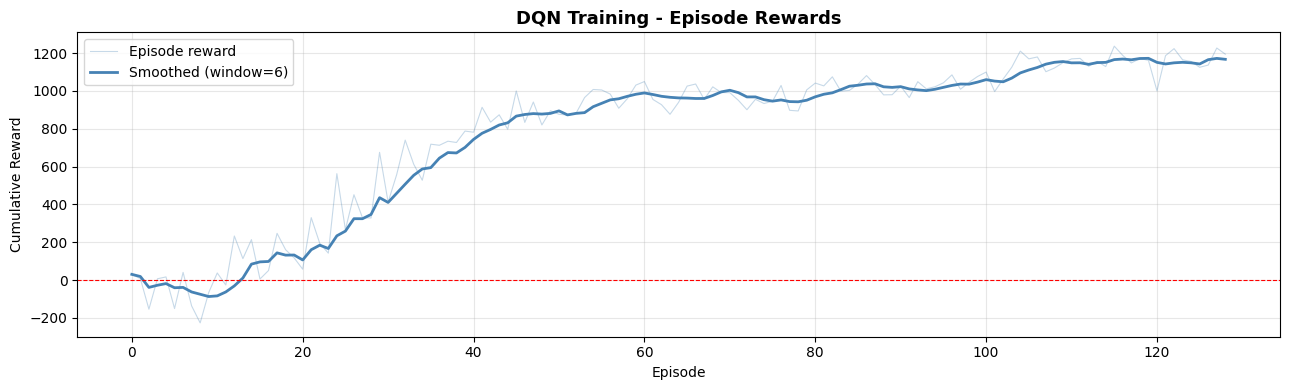

In [15]:
rewards  = logger_cb.episode_rewards
window   = max(1, len(rewards) // 20)
smoothed = pd.Series(rewards).rolling(window, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rewards,  alpha=0.3, color='steelblue', lw=0.8, label='Episode reward')
ax.plot(smoothed, color='steelblue', lw=2,       label=f'Smoothed (window={window})')
ax.axhline(0, color='red', linestyle='--', lw=0.8)
ax.set_title('DQN Training - Episode Rewards', fontsize=13, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluate on Test Set  +  Collect Actions

In [16]:
# Use in-memory model (no unnecessary disk reload)
test_env     = ForexTradingEnv(df_test, FEATURE_COLS, scaler=train_scaler)
obs, _       = test_env.reset()
actions_taken: list[int] = []

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    actions_taken.append(int(action))
    obs, reward, terminated, truncated, _ = test_env.step(action)
    done = terminated or truncated

# ── Performance Metrics ────────────────────────────────────────────────
portfolio    = np.array(test_env.portfolio_value)
returns      = np.diff(portfolio) / (portfolio[:-1] + 1e-10)
total_return = (portfolio[-1] - portfolio[0]) / portfolio[0] * 100

annual_ret   = total_return / (len(portfolio) / 252)   # annualised
sharpe       = (returns.mean() / (returns.std() + 1e-10)) * np.sqrt(252)

downside     = returns[returns < 0]
sortino      = (returns.mean() / (downside.std() + 1e-10)) * np.sqrt(252)

running_max  = np.maximum.accumulate(portfolio)
drawdowns    = (portfolio - running_max) / (running_max + 1e-10)
max_dd       = drawdowns.min() * 100
calmar       = annual_ret / (abs(max_dd) + 1e-10)

n_trades     = len(test_env.trade_history)
win_trades   = sum(1 for t in test_env.trade_history if t['pnl'] > 0)
win_rate     = win_trades / n_trades * 100 if n_trades else 0.0

print('=' * 50)
print('         TEST SET PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Starting Balance : ${test_env.initial_balance:>10,.2f}')
print(f'  Final Balance    : ${portfolio[-1]:>10,.2f}')
print(f'  Total Return     : {total_return:>10.2f}%')
print(f'  Annualised Return: {annual_ret:>10.2f}%')
print(f'  Sharpe Ratio     : {sharpe:>10.3f}')
print(f'  Sortino Ratio    : {sortino:>10.3f}')
print(f'  Calmar Ratio     : {calmar:>10.3f}')
print(f'  Max Drawdown     : {max_dd:>10.2f}%')
print(f'  Total Trades     : {n_trades:>10d}')
print(f'  Win Rate         : {win_rate:>10.1f}%')
print('=' * 50)

         TEST SET PERFORMANCE SUMMARY
  Starting Balance : $ 10,000.00
  Final Balance    : $ 10,040.67
  Total Return     :       0.41%
  Annualised Return:       0.57%
  Sharpe Ratio     :      0.983
  Sortino Ratio    :      1.195
  Calmar Ratio     :      1.425
  Max Drawdown     :      -0.40%
  Total Trades     :         23
  Win Rate         :       65.2%


## Portfolio vs Buy & Hold

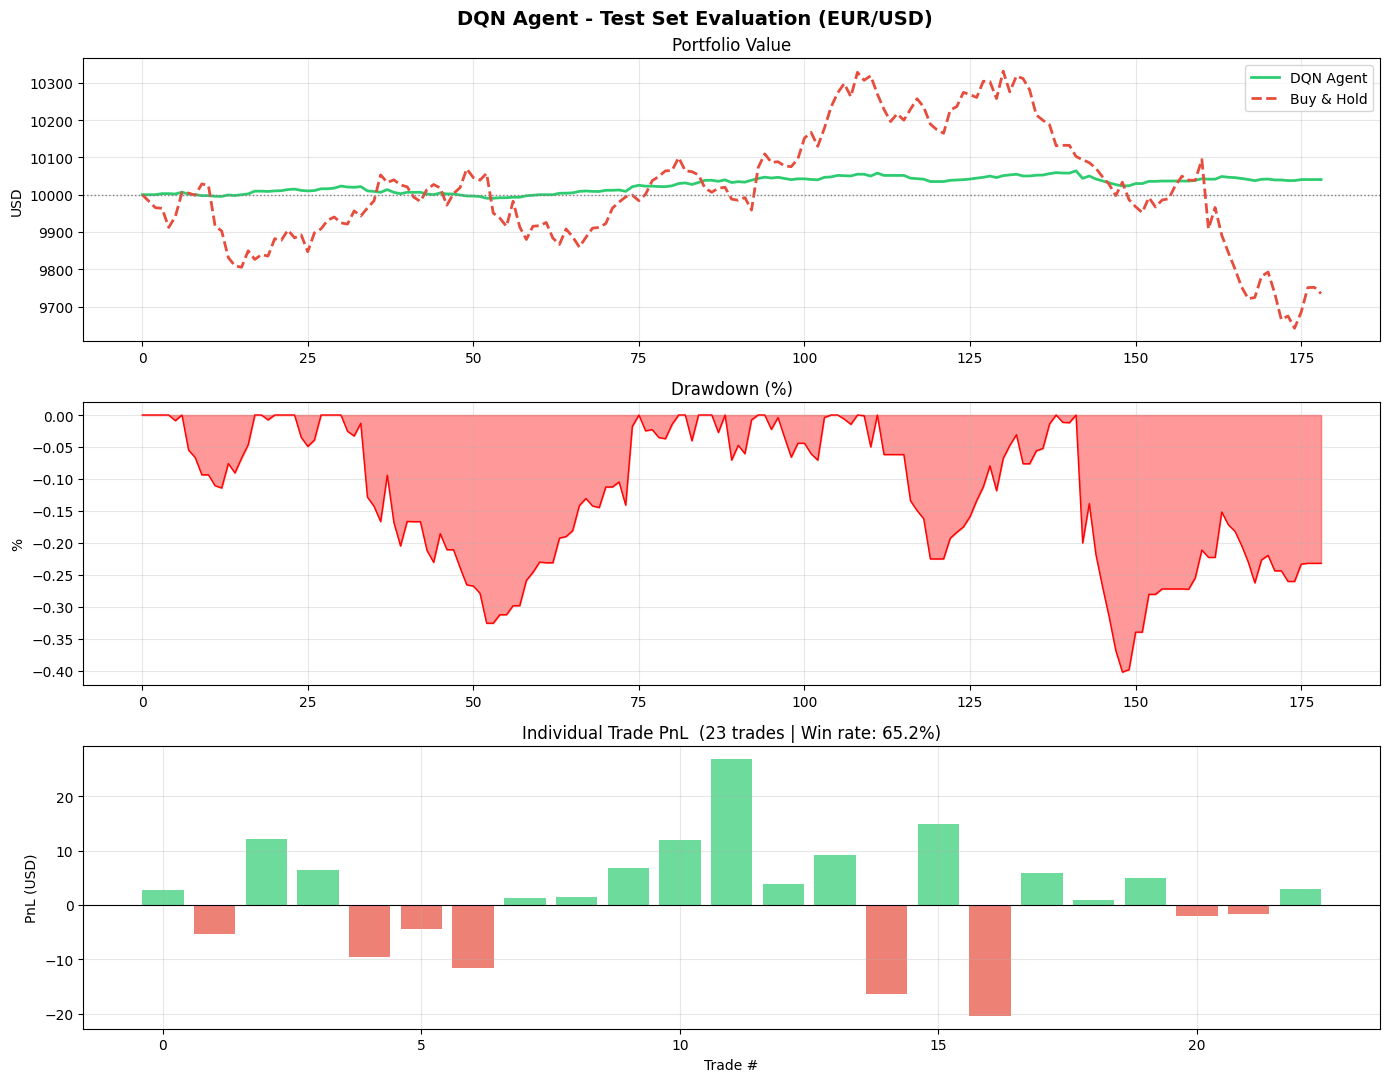

In [18]:
bh_prices  = df_test['Close'].values[:len(portfolio)]
bh_value   = (bh_prices / bh_prices[0]) * test_env.initial_balance

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('DQN Agent - Test Set Evaluation (EUR/USD)', fontsize=14, fontweight='bold')

# Portfolio value
ax = axes[0]
ax.plot(portfolio, color='#2ecc71', lw=2,  label='DQN Agent')
ax.plot(bh_value,  color='#e74c3c', lw=2,  label='Buy & Hold', linestyle='--')
ax.axhline(test_env.initial_balance, color='grey', linestyle=':', lw=1)
ax.set_title('Portfolio Value')
ax.set_ylabel('USD')
ax.legend()
ax.grid(True, alpha=0.3)

# Drawdown
ax = axes[1]
dd_pct = drawdowns * 100
ax.fill_between(range(len(dd_pct)), dd_pct, 0, alpha=0.4, color='red')
ax.plot(dd_pct, color='red', lw=1)
ax.set_title('Drawdown (%)')
ax.set_ylabel('%')
ax.grid(True, alpha=0.3)

# Trade PnL
ax = axes[2]
if test_env.trade_history:
    pnls   = [t['pnl'] for t in test_env.trade_history]
    colors = ['#2ecc71' if p > 0 else '#e74c3c' for p in pnls]
    ax.bar(range(len(pnls)), pnls, color=colors, alpha=0.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Individual Trade PnL  ({n_trades} trades | Win rate: {win_rate:.1f}%)')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('PnL (USD)')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No trades executed', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.show()

## Action Distribution Analysis

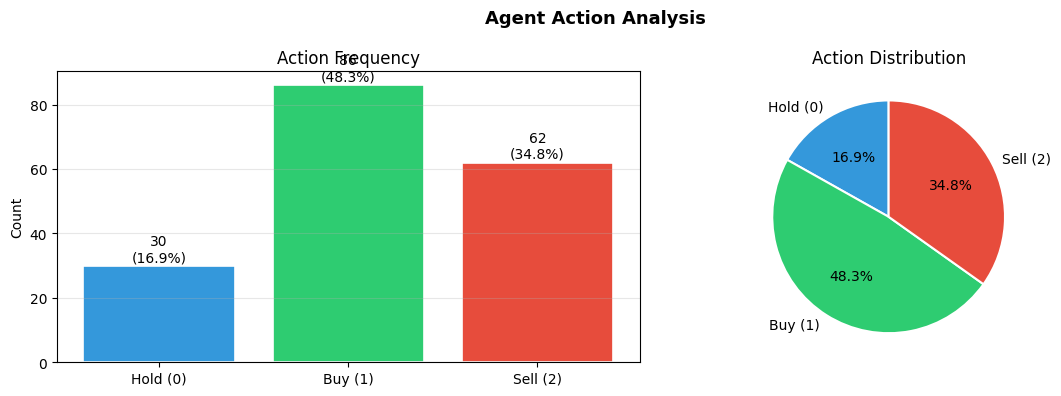

Total steps  : 178
  Hold (0)    :   30  (16.9%)
  Buy (1)     :   86  (48.3%)
  Sell (2)    :   62  (34.8%)


In [20]:
# Actions collected during the single eval loop above — no second pass needed
action_labels = ['Hold (0)', 'Buy (1)', 'Sell (2)']
counts        = [actions_taken.count(i) for i in range(3)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Agent Action Analysis', fontsize=13, fontweight='bold')

bars = ax1.bar(action_labels, counts, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white', lw=1.2)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}\n({count/len(actions_taken)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)
ax1.set_title('Action Frequency')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3, axis='y')

ax2.pie(counts, labels=action_labels, autopct='%1.1f%%',
        colors=['#3498db', '#2ecc71', '#e74c3c'], startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Action Distribution')

plt.tight_layout()
plt.show()

print(f'Total steps  : {len(actions_taken)}')
for i, lbl in enumerate(action_labels):
    print(f'  {lbl:12s}: {counts[i]:4d}  ({counts[i]/len(actions_taken)*100:.1f}%)')